#**1. Modelling Travel Time**

(a)\
For bus:\
&emsp;&emsp;Bus travel time, $T_b(x, y) = a x^2 + b y^2$
<br/>
<br/>
&emsp;&emsp;Partial derivative with respect to $x$, $\frac{\partial T_b}{\partial x} = 2 a x$
<br/>
<br/>
&emsp;&emsp;Partial derivative with respect to $y$, $\frac{\partial T_b}{\partial y} = 2 b y$
<br/>
<br/>
&emsp;&emsp;$\therefore$ Gradient for bus travel time, $\nabla T_b = (2 a x, 2 b y)$
<br/>
<br/>
For taxi:\
&emsp;&emsp;Taxi travel time, $T_t(x, y) = \sqrt{c(x^2 + y^2)}$
<br/>
<br/>
&emsp;&emsp;Partial derivative with respect to $x$, $\quad \frac{\partial T_t}{\partial x} = \frac{x\sqrt{c(x^2+y^2)}}{x^2+y^2}$
<br/>
<br/>
&emsp;&emsp;Partial derivative with respect to $y$, $\quad \frac{\partial T_t}{\partial y} = \frac{y\sqrt{c(x^2+y^2)}}{x^2+y^2}$
<br/>
<br/>
&emsp;&emsp;$\therefore$ Gradient for taxi travel time, $\nabla T_t = \left( \frac{x\sqrt{c(x^2+y^2)}}{x^2+y^2}, \frac{y\sqrt{c(x^2+y^2)}}{x^2+y^2} \right)$

In [ ]:
import sympy as sp

x, y, a, b, c = sp.symbols('x y a b c')

Tb = a * x**2 + b * y**2
gradient_Tb = (sp.diff(Tb, x), sp.diff(Tb, y))
print("Gradient for Bus:", gradient_Tb)

Tt = sp.sqrt(c * (x**2 + y**2))
gradient_Tt = (sp.diff(Tt, x), sp.diff(Tt, y))
print("Gradient for Taxi:", gradient_Tt)

Gradient for Bus: (2*a*x, 2*b*y)
Gradient for Taxi: (x*sqrt(c*(x**2 + y**2))/(x**2 + y**2), y*sqrt(c*(x**2 + y**2))/(x**2 + y**2))


(b) For the bus, the gradient components are independent. The effect of distance $x$ increases linearly with $x$ and the coefficient $a$, which represents stops and boarding time. The effect of traffic delay $y$ increases with $y$ and the coefficient $b$, which represents congestion. If $a > b$, distance has a greater impact on travel time, especially on routes with many stops. However, in practice, buses are more affected by congestion due to fixed routes. So, $b$ may be larger, making traffic delay the dominant factor.
<br/>
<br/>
For the taxi, the effects of distance and traffic delay are coupled through the euclidean norm $\sqrt{x^2 + y^2}$ of the vector $(x,y)$. This means their impacts are combined rather than independent. The contribution of each factor depends on its relative size. If traffic delay $y$ is large compared to distance $x$, additional distance has a smaller marginal effect on travel time. Therefore, taxis are influenced by both distance and traffic together. In congested cities like Colombo, traffic congestion often has a greater effect than the distance, since flexible routing can reduce distance but cannot avoid heavy traffic.

#**2. Cost Analysis Using Integration**

(a)\
Bus fare function:\
&emsp;&emsp;$F_b(x) = \int_0^x (2t + 1) dt$
<br/>
<br/>
Taxi fare function:\
&emsp;&emsp;$F_t(x) = \int_0^x (3t + 2) dt$

In [ ]:
import sympy as sp

x, t = sp.symbols('x t')

Fb = sp.integrate(2*t + 1, (t, 0, x))
Ft = sp.integrate(3*t + 2, (t, 0, x))

print(Fb)
print(Ft)

x**2 + x
3*x**2/2 + 2*x


Computed integrals:\
&emsp;&emsp;$F_b(x) = x^2 + x$
<br/>
<br/>
&emsp;&emsp;$F_t(x) = \frac{3}{2} x^2 + 2 x$

(b) Fare vs. Distance Plot

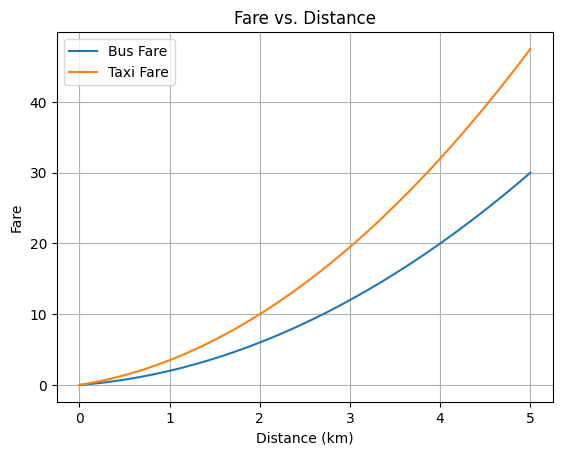

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(0, 5, 100)
fb_values = x_values**2 + x_values
ft_values = (3/2)*x_values**2 + 2*x_values

plt.plot(x_values, fb_values, label='Bus Fare')
plt.plot(x_values, ft_values, label='Taxi Fare')
plt.xlabel('Distance (km)')
plt.ylabel('Fare')
plt.title('Fare vs. Distance')
plt.legend()
plt.grid(True)
plt.show()

(c) For short trips, both bus and taxi fares are relatively affordable, but the bus is still cheaper than the taxi. As trip distance increases, the bus fare rises slowly, remaining affordable for longer journeys. On the other hand, the taxi fare increases more rapidly, making taxis increasingly less affordable for long trips. Therefore, buses are more affordable for long-distance travel, while taxis are comparatively more expensive, especially for longer trips.

#**3. Predicting Peak Travel Times Using Series Convergence**

(a)\
Passenger volume (in hundreds):\
&emsp;&emsp;$P(t) = 5 + 4\sin(\pi t) - \frac{3}{2}t^2 + \frac{t^4}{4} + \dots, \quad t \in [0, 24]$
<br/>
<br/>
Approximation with first 4 terms:\
&emsp;&emsp;$P(t) \approx 5 + 4 \sin(\pi t) - \frac{3}{2} t^2 + \frac{1}{4} t^4$

(b) Passenger Volume over 24 Hours Plot

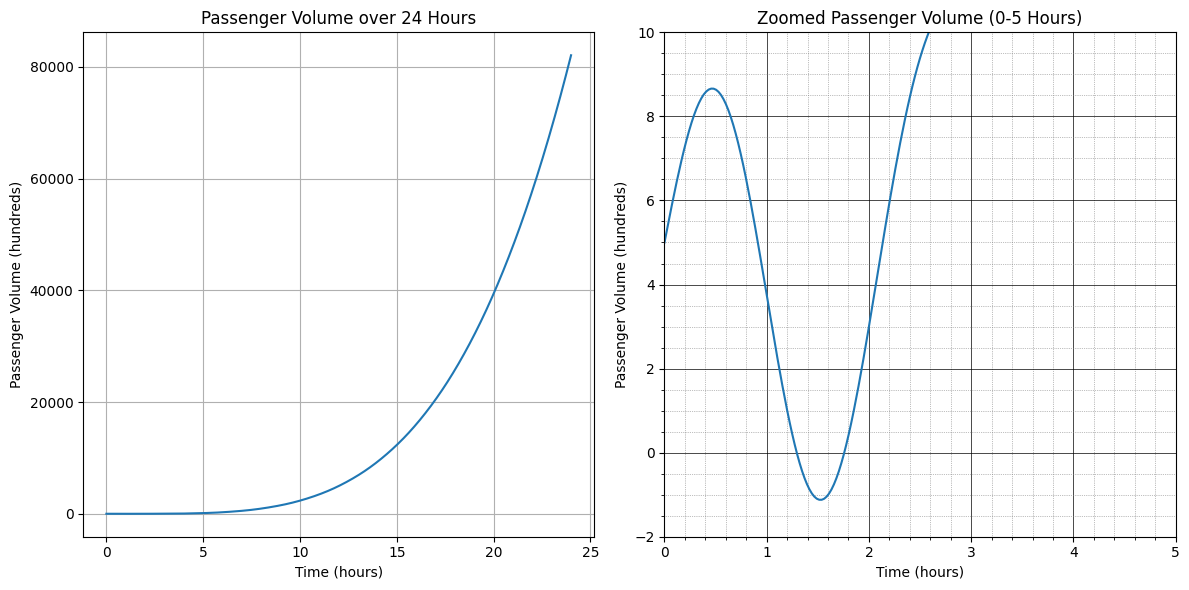

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t_values = np.linspace(0, 24, 1000)
p_values = 5 + 4*np.sin(np.pi * t_values) - 1.5 * t_values**2 + 0.25 * t_values**4

# Passenger volume over 24 hours
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t_values, p_values)
plt.xlabel('Time (hours)')
plt.ylabel('Passenger Volume (hundreds)')
plt.title('Passenger Volume over 24 Hours')
plt.grid(True)

# Zoomed passenger volume (0-5 hours)
plt.subplot(1, 2, 2)
plt.plot(t_values, p_values)
plt.xlim(0, 5)
plt.ylim(-2, 10)
plt.xlabel('Time (hours)')
plt.ylabel('Passenger Volume (hundreds)')
plt.title('Zoomed Passenger Volume (0-5 Hours)')
plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth=0.5, color='black')
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

plt.tight_layout()
plt.show()

(c) Based on the graph created by the approximation, two distinct features can be seen. The first is a realistic peak at $t = 0.5$, occuring 30 minutes into the daily cycle. Here the passenger volume reaches about 870. This peak is genuine and is driven by the sin wave component. That indicates a cyclic demand pattern. However, the graph also shows a massive rise at the end of the 24 hour period ($t = 24$), where the volume reaches over 8 million. This second peak is not real. It occurs because the model relies on a truncated power series with dominant $+ \frac{t^4}{4}$ term. In such approximations, the higher power terms eventually grow too large and cause the graph to explode upwards. Since 8 million passengers is physically impossible, the divergence represents the model breaking down rather than a genuine traffic surge. Therefore, the only valid peak shown is one at $t = 0.5$.

#**4. Travel Pattern Analysis Using Fourier Transform**

(a) Applying Fourier Transform to the boarding count data

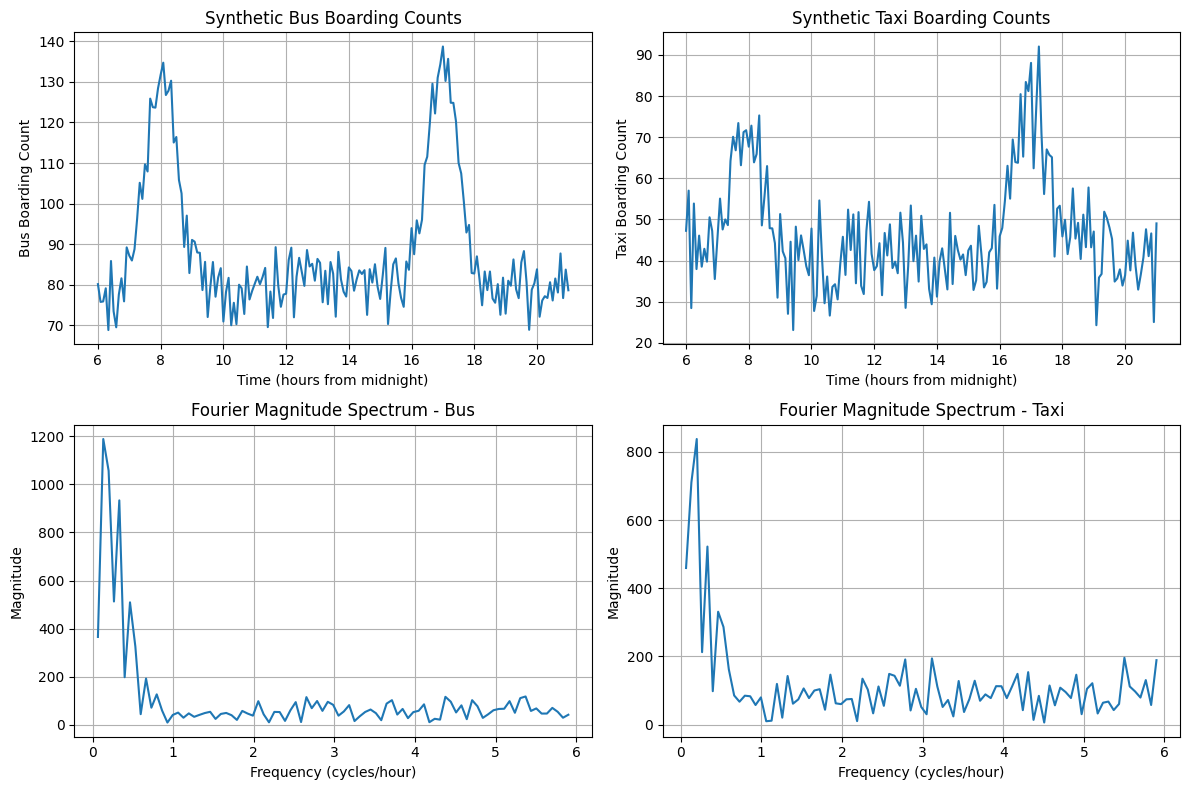


Dominant Bus Frequency: 0.133 cycles/hour
Dominant Taxi Frequency: 0.199 cycles/hour


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time array (hours from 6 AM, 181 points for 180 5-min intervals)
t_hours = np.linspace(0, 15, 181)

# Synthetic bus data: Higher base, strong morning (8 AM) and evening (5 PM) peaks and noise
bus_boarding = 80 + 50 * np.exp(-((t_hours - 2)**2 / 0.5)) + 50 * np.exp(-((t_hours - 11)**2 / 0.5)) + 5 * np.random.randn(181)

# Synthetic taxi data: Lower base, strong morning (8 AM) and evening (5 PM) peaks and more noise for variability
taxi_boarding = 40 + 30 * np.exp(-((t_hours - 2)**2 / 0.5)) + 40 * np.exp(-((t_hours - 11)**2 / 0.5)) + 8 * np.random.randn(181)

# Fourier Transform for bus
fft_bus = np.fft.fft(bus_boarding)
mag_bus = np.abs(fft_bus)

# Fourier Transform for taxi
fft_taxi = np.fft.fft(taxi_boarding)
mag_taxi = np.abs(fft_taxi)

# Frequency in cycles/hour
freq = np.fft.fftfreq(len(t_hours), d=5/60.0)

# Original data plots
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.plot(t_hours + 6, bus_boarding)
plt.xlabel('Time (hours from midnight)')
plt.ylabel('Bus Boarding Count')
plt.title('Synthetic Bus Boarding Counts')
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(t_hours + 6, taxi_boarding)
plt.xlabel('Time (hours from midnight)')
plt.ylabel('Taxi Boarding Count')
plt.title('Synthetic Taxi Boarding Counts')
plt.grid(True)

# Magnitude spectra plots
plt.subplot(2,2,3)
plt.plot(freq[1:len(freq)//2], mag_bus[1:len(freq)//2])
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Magnitude')
plt.title('Fourier Magnitude Spectrum - Bus')
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(freq[1:len(freq)//2], mag_taxi[1:len(freq)//2])
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Magnitude')
plt.title('Fourier Magnitude Spectrum - Taxi')
plt.grid(True)

plt.tight_layout()
plt.show()

# Finding dominant frequancies
pos_mask = freq > 0
freq_pos = freq[pos_mask]
mag_bus_pos = mag_bus[pos_mask]
mag_taxi_pos = mag_taxi[pos_mask]
dominant_freq_bus = freq_pos[np.argmax(mag_bus_pos)]
dominant_freq_taxi = freq_pos[np.argmax(mag_taxi_pos)]

print(f"\nDominant Bus Frequency: {dominant_freq_bus:.3f} cycles/hour")
print(f"Dominant Taxi Frequency: {dominant_freq_taxi:.3f} cycles/hour")


(b) Both the bus and taxi spectra show strong dominant peaks at low frequencies. This confirms that both modes follow the exact same morning and evening rush hour cycles. However, the bus spectrum is clean with a sharp drop-off, whereas the taxi spectrum shows relatively higher energy across high frequencies. This shows that while the major daily trends are identical, taxi demand still contains more randomness than the bus.

(c) The dominant frequencies in both the bus and taxi data occur at the same low frequencies, corresponding to the morning and evening rush hours. This shows that demand for both transport modes follows a predictable daily pattern. This allows base service capacity to be scheduled in advance around these peak periods. The bus signal is relatively smooth, with little high frequency variation, indicating stable and repeatable demand. Therefore, fixed timetables remain an efficient scheduling strategy for buses. In contrast, taxi demand, while still showing clear peak periods, also contains more high frequency fluctuations. As a result, taxi operations benefit from a hybrid scheduling approach, where a core number of drivers are scheduled for known peak hours, while additional flexible capacity is maintained to handle short term demand variability.

#**5. Image Processing Using Fourier and Discrete Cosine Transforms**

(a) Loading the image, converting to grayscale, and differentiating plates:

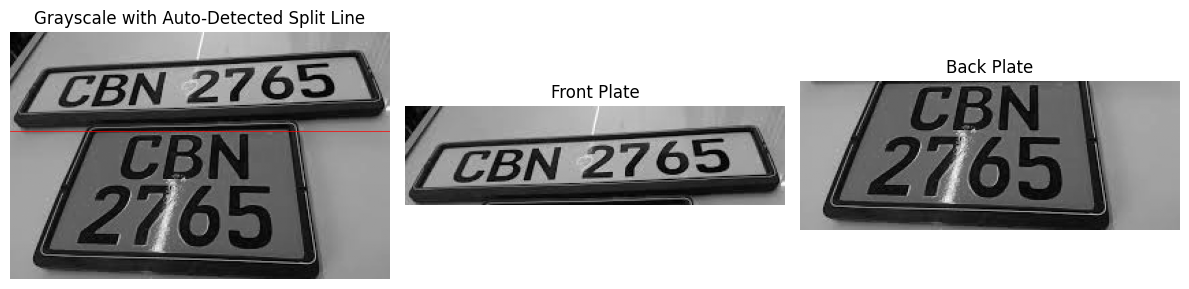

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Loading the image
img = plt.imread('vehicle_plate.png')

# Converting to grayscale
if len(img.shape) == 3:
    gray = np.mean(img, axis=2)
else:
    gray = img

# Image split point detection
# Calculating row wise brightness change
row_brightness = np.mean(gray, axis=1)

# Calculating brightness differences between consecutive rows
row_differences = np.abs(np.diff(row_brightness))

# Finding the row with the biggest brightness change
biggest_change_row = np.argmax(row_differences)

# Using the detected row as the split row
split_row = biggest_change_row

# Splitting the image
front_plate = gray[:split_row, :]
back_plate = gray[split_row:, :]

plt.figure(figsize=(12, 4))

# Original grayscale with split line
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.axhline(y=split_row, color='red', linewidth=0.5)
plt.title('Grayscale with Auto-Detected Split Line')
plt.axis('off')

# Front plate
plt.subplot(1, 3, 2)
plt.imshow(front_plate, cmap='gray')
plt.title('Front Plate')
plt.axis('off')

# Back plate
plt.subplot(1, 3, 3)
plt.imshow(back_plate, cmap='gray')
plt.title('Back Plate')
plt.axis('off')

plt.tight_layout()
plt.show()

(b) Applying 2D Fourier Transform and visualizing magnitude:

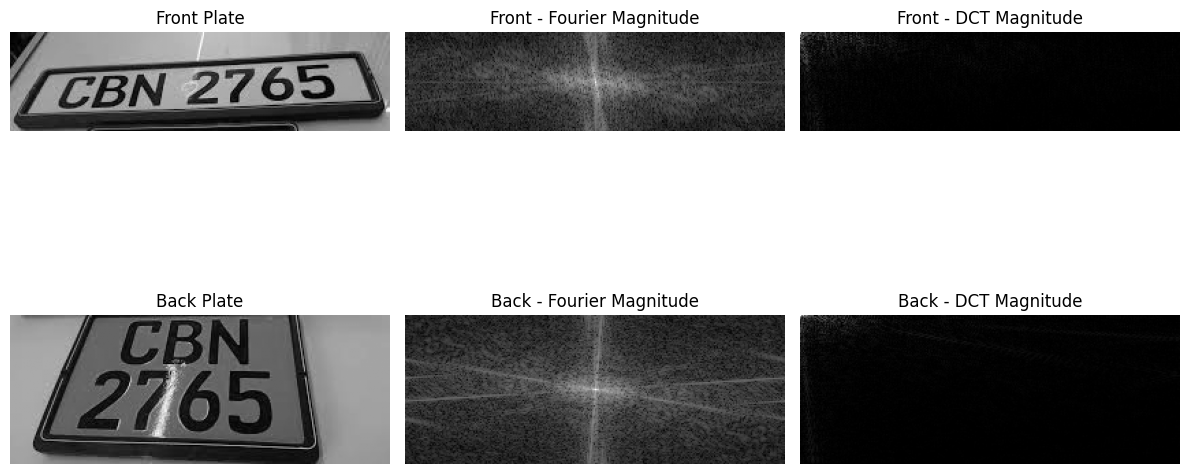

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack

# Applying fourier transform to front plate
fft_front = fftpack.fft2(front_plate)
fft_front_shifted = fftpack.fftshift(fft_front)
magnitude_fft_front = np.log(np.abs(fft_front_shifted) + 1)

# Applying fourier transform to back plate
fft_back = fftpack.fft2(back_plate)
fft_back_shifted = fftpack.fftshift(fft_back)
magnitude_fft_back = np.log(np.abs(fft_back_shifted) + 1)

# Applying DCT for front plate
dct_front = fftpack.dct(fftpack.dct(front_plate.T, norm='ortho').T, norm='ortho')
magnitude_dct_front = np.log(np.abs(dct_front) + 1)

# Applying DCT for back plate
dct_back = fftpack.dct(fftpack.dct(back_plate.T, norm='ortho').T, norm='ortho')
magnitude_dct_back = np.log(np.abs(dct_back) + 1)

plt.figure(figsize=(12, 8))

# Front plate
plt.subplot(2, 3, 1)
plt.imshow(front_plate, cmap='gray')
plt.title('Front Plate')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude_fft_front, cmap='gray')
plt.title('Front - Fourier Magnitude')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(magnitude_dct_front, cmap='gray')
plt.title('Front - DCT Magnitude')
plt.axis('off')

# Back plate
plt.subplot(2, 3, 4)
plt.imshow(back_plate, cmap='gray')
plt.title('Back Plate')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(magnitude_fft_back, cmap='gray')
plt.title('Back - Fourier Magnitude')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(magnitude_dct_back, cmap='gray')
plt.title('Back - DCT Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

(c) Basic number plate localization using edge detection and contour analysis:

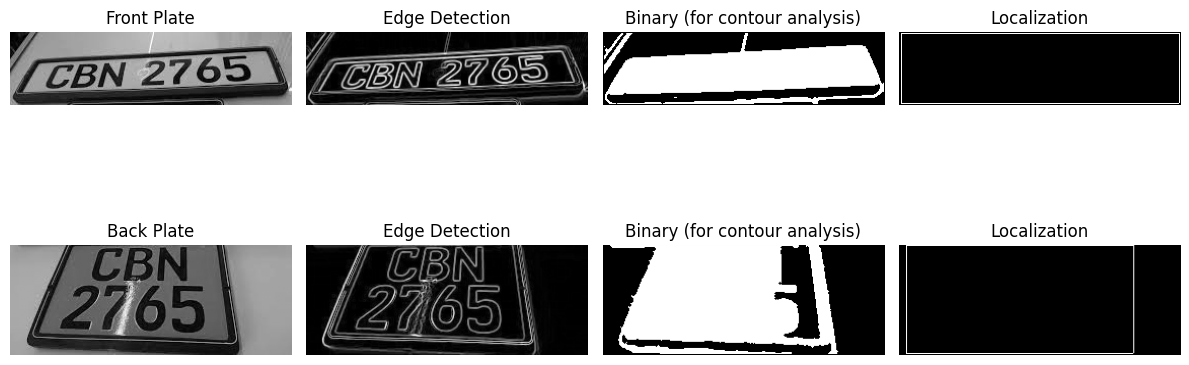

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import label

def find_license_plate(image, plate_name="Plate"):

    # Enhancing contrast to make edges clear
    enhanced = np.clip(image * 1.5, 0, 255)

    # Edge detection
    edge_x = ndimage.sobel(enhanced, axis=0)
    edge_y = ndimage.sobel(enhanced, axis=1)
    edges = np.sqrt(edge_x**2 + edge_y**2)

    # Creating binary image from edges
    threshold = np.percentile(edges, 70)
    binary = edges > threshold

    # Cleaning binary image
    binary = ndimage.binary_closing(binary) # Connecting nearby white pixels
    binary = ndimage.binary_fill_holes(binary) # Filling gaps inside shape

    # Contour detection
    labels, num_shapes = label(binary)

    # Looking for plate shaped contours
    result = image.copy()
    plate_found = False

    if num_shapes > 0:
        for i in range(1, num_shapes + 1): # Checking each shape
            # Get bounding box coordinates
            rows = np.any(labels == i, axis=1)
            cols = np.any(labels == i, axis=0)

            # Skipping if shape has no area
            if not any(rows) or not any(cols):
                continue

            # Finding bounderies
            top, bottom = np.where(rows)[0][[0, -1]]
            left, right = np.where(cols)[0][[0, -1]]

            height = bottom - top
            width = right - left

            # Checking if it looks like a license plate
            if width > 0 and height > 0:
                aspect = width / height
                if 2.0 < aspect < 6.0:
                    # Drawing a white box around plate
                    result[top:bottom, left] = 255
                    result[top:bottom, right] = 255
                    result[top, left:right] = 255
                    result[bottom, left:right] = 255

                    plate_found = True
                    break

    if not plate_found:
        print(f"{plate_name}: No plate found")

    return edges, binary, result, plate_found

# Processing both plates
edges_f, binary_f, marked_f, found_f = find_license_plate(front_plate, "Front")
edges_b, binary_b, marked_b, found_b = find_license_plate(back_plate, "Back")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Front plate row
axes[0, 0].imshow(front_plate, cmap='gray')
axes[0, 0].set_title('Front Plate')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_f, cmap='gray')
axes[0, 1].set_title('Edge Detection')
axes[0, 1].axis('off')

axes[0, 2].imshow(binary_f, cmap='gray')
axes[0, 2].set_title('Binary (for contour analysis)')
axes[0, 2].axis('off')

axes[0, 3].imshow(marked_f, cmap='gray')
axes[0, 3].set_title('Localization' if found_f else 'Not Found')
axes[0, 3].axis('off')

# Back plate row
axes[1, 0].imshow(back_plate, cmap='gray')
axes[1, 0].set_title('Back Plate')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_b, cmap='gray')
axes[1, 1].set_title('Edge Detection')
axes[1, 1].axis('off')

axes[1, 2].imshow(binary_b, cmap='gray')
axes[1, 2].set_title('Binary (for contour analysis)')
axes[1, 2].axis('off')

axes[1, 3].imshow(marked_b, cmap='gray')
axes[1, 3].set_title('Localization' if found_b else 'Not Found')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

(d) The transforms reveal that the license plates are structurally simple, dominated by smooth background and sharp edges. The fourier spectrum shows strong directional patterns like vertical lines corresspond to horizontal borders, while starburst patterns indicate diagonal character strokes. And also the scissors shape indicates the plate isn't perfectly frontal, showing both horizontal and vertical edges at angles. The DCT concentrates energy in the top left corner, confirming that the most information is in low frequency background areas, with sparse high frequency details from text. This indicates a structure with large uniform regions and localized, high contrast features.

Fourier and DCT transforms improve plate recognition by cleaning images before processing. They remove noise through frequency filtering, normalize different lighting conditions, and compares images for efficient storage. Most importantly, fourier analysis detects plate orientation, making sure the system reads text correctly even when plates are tilted. This preprocessing makes edge detection and character recognition more accurate in varying conditions.

Recognized plates enable real time traffic management. Systems can count vehicles to identify congested routes, measure travel speeds, and detect traffic violations. This data improves traffic light timing, provides alternative routes during jams, and clears paths for emergency vehicles. Long term analysis helps cities redesign problem intersections, improve public transport scheduling, and reduce overall congestion through data driven decisions.